# Basketball Monte Carlo Pricer

This notebook prices a Team A winner contract under the baseline compound Poisson score model by simulating the terminal point margin directly from the six independent Poisson basket counts. It also generates exact jump paths for a small number of sample games so the underlying score dynamics can be visualized.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np

project_root = Path.cwd()
if not (project_root / "src").exists() and (project_root.parent / "src").exists():
    project_root = project_root.parent

src_path = project_root / "src"
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

from MonteCarlo import MonteCarlo

## Contract parameters

In [2]:
contract = {
    "lambda_a": 22.0,
    "lambda_b": 21.0,
    "p_a": [0.08, 0.72, 0.20],
    "p_b": [0.09, 0.71, 0.20],
    "T": 2.0,
    "contract_type": "team_a_yes",
}

num_simulations = 100_000
seed = 42

## Price the contract

In [3]:
pricer = MonteCarlo(contract, num_simulations=num_simulations, seed=seed)
results = pricer.price()
results

{'price': 0.58272,
 'standard_error': 0.0015593505109499917,
 'confidence_interval': (0.579663672998538, 0.585776327001462),
 'num_simulations': 100000,
 'seed': 42}

In [4]:
ci_low, ci_high = results["confidence_interval"]

print(f"Price estimate: {results['price']:.6f}")
print(f"Standard error: {results['standard_error']:.6f}")
print(f"95% confidence interval: [{ci_low:.6f}, {ci_high:.6f}]")

Price estimate: 0.582720
Standard error: 0.001559
95% confidence interval: [0.579664, 0.585776]


## Convergence diagnostics

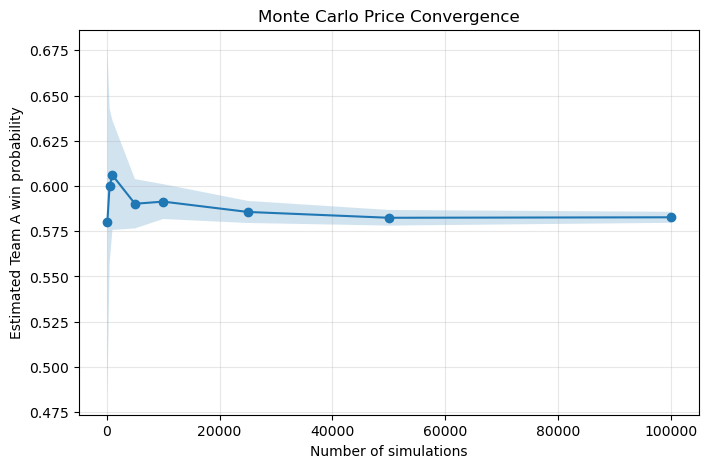

In [5]:
checkpoints = [100, 500, 1_000, 5_000, 10_000, 25_000, 50_000, 100_000]
convergence = pricer.convergence(checkpoints)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(convergence["checkpoints"], convergence["estimates"], marker="o", linewidth=1.5)
ax.fill_between(
    convergence["checkpoints"],
    convergence["ci_low"],
    convergence["ci_high"],
    alpha=0.2,
)
ax.set_title("Monte Carlo Price Convergence")
ax.set_xlabel("Number of simulations")
ax.set_ylabel("Estimated Team A win probability")
ax.grid(True, alpha=0.3)
plt.show()

## Simulated point-margin distribution

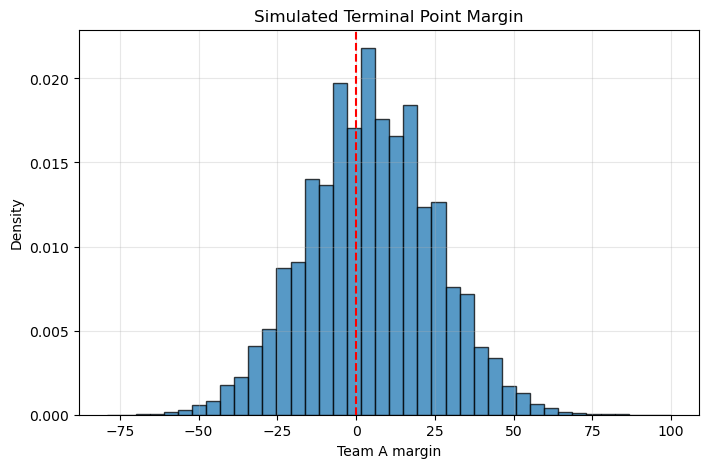

In [6]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(pricer.margins, bins=40, density=True, alpha=0.75, edgecolor="black")
ax.axvline(0, color="red", linestyle="--", linewidth=1.5)
ax.set_title("Simulated Terminal Point Margin")
ax.set_xlabel("Team A margin")
ax.set_ylabel("Density")
ax.grid(True, alpha=0.3)
plt.show()

## Sample jump paths

In [10]:
path_samples = pricer.simulate_paths(num_paths=10)

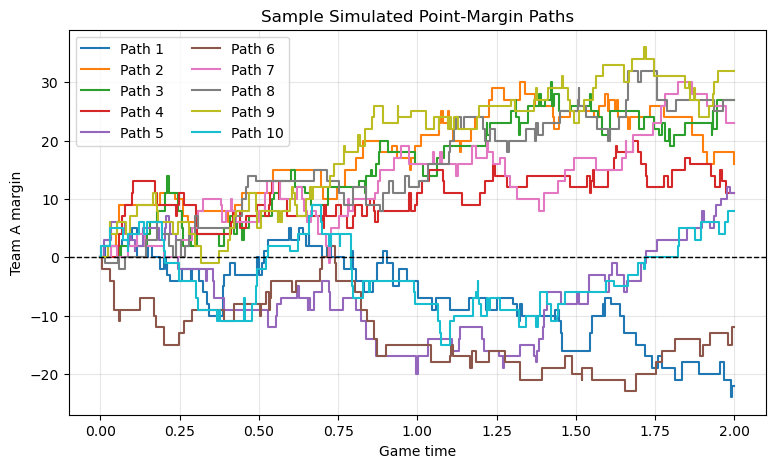

In [11]:
fig, ax = plt.subplots(figsize=(9, 5))
for index, path in enumerate(path_samples, start=1):
    ax.step(path["times"], path["margin"], where="post", linewidth=1.5, label=f"Path {index}")

ax.axhline(0, color="black", linestyle="--", linewidth=1.0)
ax.set_title("Sample Simulated Point-Margin Paths")
ax.set_xlabel("Game time")
ax.set_ylabel("Team A margin")
ax.grid(True, alpha=0.3)
ax.legend(ncol=2)
plt.show()

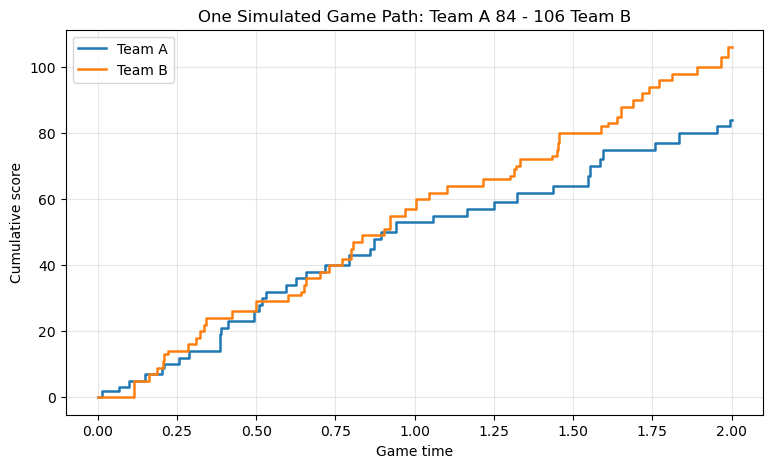

In [14]:
sample_path = path_samples[0]

fig, ax = plt.subplots(figsize=(9, 5))
ax.step(sample_path["times"], sample_path["score_a"], where="post", linewidth=1.8, label="Team A")
ax.step(sample_path["times"], sample_path["score_b"], where="post", linewidth=1.8, label="Team B")
ax.set_title(
    f"One Simulated Game Path: Team A {sample_path['final_score_a']} - {sample_path['final_score_b']} Team B"
)
ax.set_xlabel("Game time")
ax.set_ylabel("Cumulative score")
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()